# QAOA Master Notebook

Welcome to the main Jupyter Notebook for the Quantum Approximate Optimization Algorithm (QAOA) implementation. 
We are building this up step-by-step.

---
## Day 1: Quantum Computing Fundamentals

Before we can write QAOA, we must master the basics of Qiskit, circuit construction, and the modern IBM Primitives.

### 0. Google Colab Setup
Since you are running this in Colab, your environment resets and doesn't have Qiskit installed by default. 
**Run the cell below once** to install the required libraries, then proceed!
*(Note: You might see a prompt to "Restart Session" afterwards. If so, restart the session and continue.)*

In [3]:
%%capture
!pip install -q qiskit qiskit-aer qiskit-ibm-runtime pylatexenc matplotlib

### 1. Setup & Imports
Let's import what we need from Qiskit.

In [4]:
from qiskit import QuantumCircuit
from qiskit.visualization import plot_histogram

# Primitives are the modern way to execute circuits in Qiskit v1.x
from qiskit.primitives import StatevectorSampler as Sampler

print("Imports successful. You are ready to go!")

Imports successful. You are ready to go!


### 2. Your First Quantum Circuit

In classical computing, a bit is either `0` or `1`. In quantum computing, we use a **qubit**, which defaults to being in the `|0>` state.

Let's create a circuit with 1 Qubit and 1 Classical Bit (to store our measurement result).

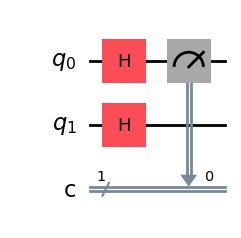

In [ ]:
# Create a Quantum Circuit acting on 1 qubit and 1 classical bit
qc = QuantumCircuit(1, 1)

# 1. Apply the Hadamard (H) gate to the qubit 0.
# The H gate puts the qubit into an equal superposition of |0> and |1>.
qc.h(0)

# 2. Measure the qubit (collapse the superposition) and store the result in classical bit 0.
qc.measure(0, 0)

# 3. Draw the circuit so we can see what we built.
qc.draw('mpl')

my version with 3 qubit

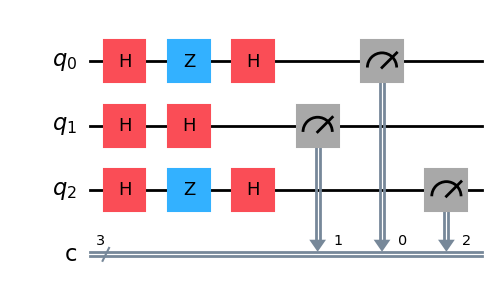

In [53]:
# Create a Quantum Circuit acting on 1 qubit and 1 classical bit
qc = QuantumCircuit(3, 3)

# 1. Apply the Hadamard (H) gate to the qubit 0.
# The H gate puts the qubit into an equal superposition of |0> and |1>.

qc.h([0,1,2])
qc.z([0,2])
qc.x(1)
qc.h([0,1,2])

# 2. Measure the qubit (collapse the superposition) and store the result in classical bit 0.
qc.measure(range(3),range(3))

# 3. Draw the circuit so we can see what we built.
qc.draw('mpl')
# qc.draw('text')

### 3. The Sampler Primitive

In older versions of Qiskit, you used `execute(circuit, backend)` to run jobs. Now, IBM provides **Primitives**.

The **Sampler** primitive samples from quantum circuits to estimate the probability distributions of the outputs.
- **When to use it:** When you need a distribution of bitstrings (e.g., getting "010", "101", etc.). This is exactly what we need for QAOA since we want to find the optimal stock subset string!

Let's run our superposition circuit through the local Sampler.

Counts: {'101': 1000}


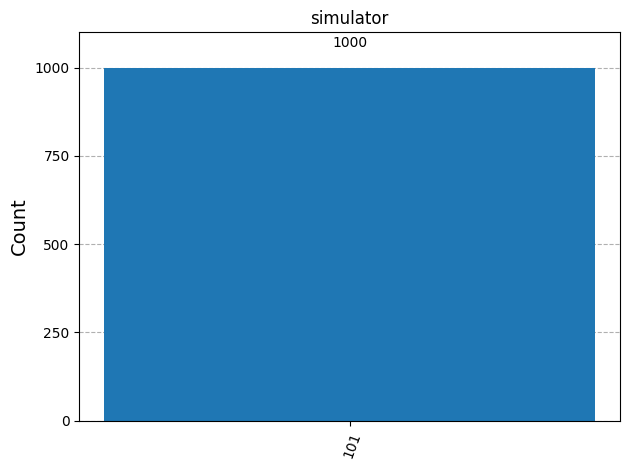

In [54]:
# Initialize the local Sampler (StatevectorSampler simulates it perfectly without noise)
sampler = Sampler()

# The Sampler uses a run() method. You must pass the circuit in a list [].
job = sampler.run([qc], shots=1000)

# Wait for the result
result = job.result()

# Extract the counts. In Qiskit 1.x, we get the result for the first circuit published via pub_result[0].
# We then access the data using the classical register name, which by default is 'c'.
pub_result = result[0]
counts = pub_result.data.c.get_counts()

print("Counts:", counts)
plot_histogram(counts,title="simulator")

**Analysis:** Because we applied a Hadamard gate, you should see roughly a 50/50 split between measuring `0` and `1`. No single execution is predictable, but over 1000 shots, the statistics converge!

### 4. Setting up your IBM Quantum Account

**Colab Upload Note:** If you are running in Colab, you need to click the "Files" folder icon on the left sidebar and upload your `apikey.json` file there before running this cell!

Looking for the least busy quantum computer...


qiskit_runtime_service.backends:WARNING:2026-04-05 06:14:24,180: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-04-05 06:14:25,457: Using instance: open-instance, plan: open


✅ Selected Backend: ibm_fez
🚀 Submitting job to ibm_fez...
Job successfully submitted!
Job ID: d78vrgpq1efs73d287p0
Dashboard: https://quantum.ibm.com/jobs
Waiting in queue for hardware execution... (You can check the dashboard link above to see your exact queue position)
Real Hardware Counts: {'101': 965, '001': 11, '100': 18, '111': 30}


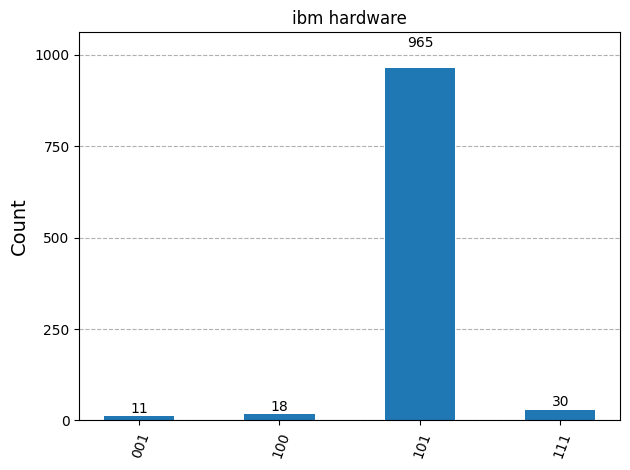

In [55]:
from qiskit_ibm_runtime import SamplerV2 as RealSampler
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit.visualization import plot_histogram

# 1. Find the least busy real quantum computer
print("Looking for the least busy quantum computer...")
backend = service.least_busy(simulator=False, operational=True)
print(f"✅ Selected Backend: {backend.name}")

# 2. Transpile the circuit for this specific hardware
# (Real hardware only understands specific instructions, so we must translate our circuit)
pass_manager = generate_preset_pass_manager(optimization_level=1, backend=backend)
isa_circuit = pass_manager.run(qc)

# 3. Initialize the real Sampler using our selected backend
real_sampler = RealSampler(mode=backend)

# 4. Submit the job!
print(f"🚀 Submitting job to {backend.name}...")
job = real_sampler.run([isa_circuit], shots=1024)

print(f"Job successfully submitted!")
print(f"Job ID: {job.job_id()}")
print("Dashboard: https://quantum.ibm.com/jobs")

# 5. Wait for the result and plot it
# WARNING: Since we are on the free tier, this cell might run for several minutes (or even hours)
# while waiting in the real-world queue! 
print("Waiting in queue for hardware execution... (You can check the dashboard link above to see your exact queue position)")

result = job.result()
pub_result = result[0]

# Extract counts from the measurement register (called 'c' by default in our earlier circuit)
counts = pub_result.data.c.get_counts()

print("Real Hardware Counts:", counts)
plot_histogram(counts,title="ibm hardware")
